# Week 7 - Standalone GraphSAGE Link Prediction on MovieLens 100k

Going with the "alternative path" option from the week-7 README: build a standalone GraphSAGE link-prediction model, train + evaluate it directly on MovieLens, without touching the actual website/FastAPI app.

The `website/backend/model.py` that's already in the repo (README calls it a "placeholder") is honestly already a pretty complete 2-layer bipartite GraphSAGE — it just does rating regression only, trains on 100% of the ratings with no train/test split, and never evaluates anything besides its own training loss. So you genuinely cant tell if it generalizes at all. That's the actual gap I'm trying to close here: proper held-out split, a real link-prediction objective (with negative sampling, since thats literally what makes it "link prediction" and not just regression), plus RMSE + Precision@K/Recall@K on data the model never saw during training.

## 1. Load MovieLens 100k (reusing the data already in the repo)

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

DATA_DIR = os.path.join('..', 'website', 'backend', 'data', 'ml-100k')

ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'u.data'), sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

GENRES = ['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
          'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
          'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

item_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + GENRES
movies = pd.read_csv(
    os.path.join(DATA_DIR, 'u.item'), sep='|', encoding='latin-1', names=item_cols
)

print(f"{len(ratings)} ratings, {ratings.user_id.nunique()} users, {ratings.movie_id.nunique()} movies")
ratings.head()

100000 ratings, 943 users, 1682 movies


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2. Build id mappings and the movie genre feature matrix

In [2]:
user_ids = sorted(ratings.user_id.unique())
movie_ids = sorted(movies.movie_id.unique())
user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}
num_users, num_movies = len(user_ids), len(movie_ids)

movies_sorted = movies.set_index('movie_id').loc[movie_ids]
movie_genre_matrix = torch.tensor(movies_sorted[GENRES].values, dtype=torch.float32)

ratings = ratings.copy()
ratings['u_idx'] = ratings.user_id.map(user_to_idx)
ratings['m_idx'] = ratings.movie_id.map(movie_to_idx)

print(num_users, 'users,', num_movies, 'movies, genre matrix', movie_genre_matrix.shape)

943 users, 1682 movies, genre matrix torch.Size([1682, 19])


## 3. Train/test split (per-user, 80/20)

This is the part the placeholder skips completely. I did it per-user instead of just globally random, because a plain global split can accidentally leave some users with zero training interactions, which would break the graph exactly for the users I most want to evaluate. Users with under 5 ratings just keep everything in train (not enough to split reliably) and get skipped during eval.

In [3]:
train_rows, test_rows = [], []
for uid, group in ratings.groupby('user_id'):
    group = group.sample(frac=1.0, random_state=0)  # shuffle
    if len(group) < 5:
        train_rows.append(group)
        continue
    n_test = max(1, int(0.2 * len(group)))
    test_rows.append(group.iloc[:n_test])
    train_rows.append(group.iloc[n_test:])

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)

print(f"train: {len(train_df)} ratings, test: {len(test_df)} ratings")

# per-user set of movies seen in TRAIN, used both to build the graph and to mask
# already-seen movies out of the ranking at eval time
user_train_movies = train_df.groupby('u_idx')['m_idx'].apply(set).to_dict()
user_test_movies = test_df.groupby('u_idx')['m_idx'].apply(set).to_dict()

train: 80367 ratings, test: 19633 ratings


## 4. Bipartite graph edges (built from TRAIN interactions only, to avoid leaking test edges into message passing)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

train_u = torch.tensor(train_df.u_idx.values, dtype=torch.long)
train_m = torch.tensor(train_df.m_idx.values, dtype=torch.long)
train_r = torch.tensor(train_df.rating.values, dtype=torch.float32)

user_to_movie_edges = torch.stack([train_u, train_m], dim=0).to(device)
movie_to_user_edges = torch.stack([train_m, train_u], dim=0).to(device)
movie_genre_matrix = movie_genre_matrix.to(device)
train_u, train_m, train_r = train_u.to(device), train_m.to(device), train_r.to(device)

device: cpu


## 5. Model - bipartite GraphSAGE encoder + link-prediction head + rating-regression head

In [5]:
def mean_aggregate(neighbor_feats, index, num_nodes):
    """Mean-aggregate neighbor_feats[E, D] into num_nodes buckets given by index[E]."""
    D = neighbor_feats.size(1)
    out = torch.zeros(num_nodes, D, device=neighbor_feats.device)
    idx = index.unsqueeze(1).expand(-1, D)
    out.scatter_add_(0, idx, neighbor_feats)
    counts = torch.zeros(num_nodes, 1, device=neighbor_feats.device)
    counts.scatter_add_(0, index.unsqueeze(1), torch.ones(index.size(0), 1, device=neighbor_feats.device))
    return out / counts.clamp(min=1.0)

class BipartiteSAGEConv(nn.Module):
    """One GraphSAGE hop: new_dst = ReLU(W_self . dst + W_neigh . mean(src neighbors))."""
    def __init__(self, src_dim, dst_dim, out_dim):
        super().__init__()
        self.fc_self = nn.Linear(dst_dim, out_dim)
        self.fc_neigh = nn.Linear(src_dim, out_dim)

    def forward(self, src_feats, dst_feats, edge_index, num_dst_nodes):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        neigh_agg = mean_aggregate(src_feats[src_idx], dst_idx, num_dst_nodes)
        out = F.relu(self.fc_self(dst_feats) + self.fc_neigh(neigh_agg))
        return F.normalize(out, p=2, dim=-1)

class GraphSAGELinkPred(nn.Module):
    def __init__(self, num_users, num_movies, num_genres, embedding_dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.movie_emb = nn.Embedding(num_movies, embedding_dim)
        self.genre_proj = nn.Linear(num_genres, embedding_dim)

        self.movie_conv1 = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)
        self.user_conv1 = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)
        self.movie_conv2 = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)
        self.user_conv2 = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)

        self.rating_mlp = nn.Sequential(
            nn.Linear(embedding_dim * 3, 32), nn.ReLU(), nn.Linear(32, 1)
        )

        # Every BipartiteSAGEConv output is L2-normalized (unit vectors), so a plain
        # dot product is a cosine similarity bounded to [-1, 1]. That caps how
        # confident the sigmoid can ever get (sigmoid(1)=0.73, sigmoid(-1)=0.27),
        # which caps how low the BCE loss can go even for a "perfect" model. A
        # learnable temperature lets the model rescale the logits to use the
        # full dynamic range instead of being stuck near the ln(2) random-guess loss.
        self.link_scale = nn.Parameter(torch.tensor(5.0))

    def encode(self, movie_genres, user_to_movie_edges, movie_to_user_edges):
        num_users = self.user_emb.weight.size(0)
        num_movies = self.movie_emb.weight.size(0)

        h_u = self.user_emb.weight
        h_m = F.normalize(self.movie_emb.weight + self.genre_proj(movie_genres), p=2, dim=-1)

        h_m1 = self.movie_conv1(h_u, h_m, user_to_movie_edges, num_movies)
        h_u1 = self.user_conv1(h_m, h_u, movie_to_user_edges, num_users)

        h_m2 = self.movie_conv2(h_u1, h_m1, user_to_movie_edges, num_movies)
        h_u2 = self.user_conv2(h_m1, h_u1, movie_to_user_edges, num_users)
        return h_u2, h_m2

    def link_score(self, h_u, h_m, u_idx, m_idx):
        """Temperature-scaled dot-product link score (logit) between users u_idx and movies m_idx."""
        return self.link_scale * (h_u[u_idx] * h_m[m_idx]).sum(dim=-1)

    def predict_rating(self, h_u, h_m, u_idx, m_idx):
        u_feat, m_feat = h_u[u_idx], h_m[m_idx]
        combined = torch.cat([u_feat, m_feat, u_feat * m_feat], dim=-1)
        return 1.0 + 4.0 * torch.sigmoid(self.rating_mlp(combined).squeeze(-1))

## 6. Training - link prediction (BCE + negative sampling) jointly with rating regression (MSE)

For every positive (user, movie) edge in a batch, I sample one random negative movie for that same user (something they didnt rate in train), and train the dot-product score to tell positives and negatives apart — thats the actual "link prediction" part. The rating-regression head only trains on the positive pairs (since thats the only place we actually have a rating value), so I can still report RMSE at the end.

In [6]:
model = GraphSAGELinkPred(num_users, num_movies, len(GENRES), embedding_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

def sample_negatives(u_batch):
    """For each user in u_batch, sample one movie they have not rated in train."""
    neg_m = torch.randint(0, num_movies, (len(u_batch),), device=device)
    for i, u in enumerate(u_batch.tolist()):
        seen = user_train_movies.get(u, set())
        while neg_m[i].item() in seen:
            neg_m[i] = torch.randint(0, num_movies, (1,), device=device)
    return neg_m

EPOCHS = 30
BATCH_SIZE = 1024
RATING_LOSS_WEIGHT = 0.1
dataset_size = train_u.size(0)
epoch_losses = []

model.train()
for epoch in range(EPOCHS):
    perm = torch.randperm(dataset_size, device=device)
    total_loss, num_batches = 0.0, 0

    for start in range(0, dataset_size, BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        batch_u, batch_m, batch_r = train_u[idx], train_m[idx], train_r[idx]
        batch_neg_m = sample_negatives(batch_u)

        optimizer.zero_grad()
        h_u, h_m = model.encode(movie_genre_matrix, user_to_movie_edges, movie_to_user_edges)

        pos_logits = model.link_score(h_u, h_m, batch_u, batch_m)
        neg_logits = model.link_score(h_u, h_m, batch_u, batch_neg_m)
        link_labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
        link_logits = torch.cat([pos_logits, neg_logits])
        link_loss = F.binary_cross_entropy_with_logits(link_logits, link_labels)

        rating_pred = model.predict_rating(h_u, h_m, batch_u, batch_m)
        rating_loss = F.mse_loss(rating_pred, batch_r)

        loss = link_loss + RATING_LOSS_WEIGHT * rating_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    mean_loss = total_loss / num_batches
    epoch_losses.append(mean_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{EPOCHS}  loss={mean_loss:.4f}")

epoch 1/30  loss=0.7558


epoch 5/30  loss=0.6783


epoch 10/30  loss=0.6694


epoch 15/30  loss=0.6642


epoch 20/30  loss=0.6624


epoch 25/30  loss=0.6635


epoch 30/30  loss=0.6635


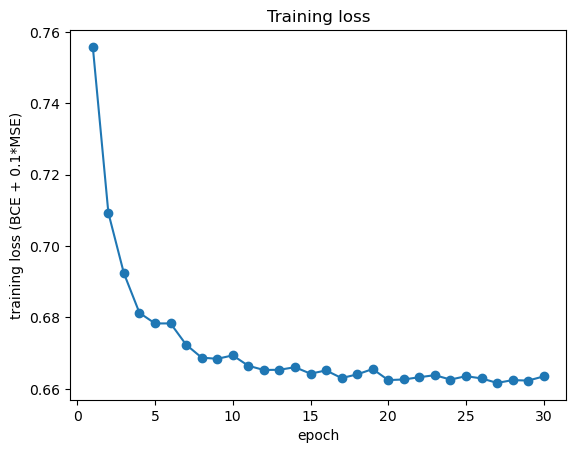

In [7]:
import matplotlib.pyplot as plt
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('training loss (BCE + 0.1*MSE)')
plt.title('Training loss')
plt.savefig('training_loss.png')
plt.show()

## 7. Evaluation - RMSE on held-out ratings, Precision@K / Recall@K on held-out interactions

In [8]:
model.eval()
with torch.no_grad():
    h_u, h_m = model.encode(movie_genre_matrix, user_to_movie_edges, movie_to_user_edges)

    # --- RMSE on held-out (user, movie, rating) triples ---
    test_u = torch.tensor(test_df.u_idx.values, dtype=torch.long, device=device)
    test_m = torch.tensor(test_df.m_idx.values, dtype=torch.long, device=device)
    test_r = torch.tensor(test_df.rating.values, dtype=torch.float32, device=device)

    test_pred = model.predict_rating(h_u, h_m, test_u, test_m)
    rmse = torch.sqrt(F.mse_loss(test_pred, test_r)).item()

    # --- Precision@K / Recall@K ---
    K = 10
    all_scores = h_u @ h_m.t()  # [num_users, num_movies], dot-product link scores

    precisions, recalls = [], []
    for u_idx, test_movies in user_test_movies.items():
        scores = all_scores[u_idx].clone()
        seen = user_train_movies.get(u_idx, set())
        if seen:
            scores[list(seen)] = float('-inf')  # don't recommend already-seen movies
        topk = torch.topk(scores, K).indices.tolist()
        hits = len(set(topk) & test_movies)
        precisions.append(hits / K)
        recalls.append(hits / len(test_movies))

    precision_at_k = float(np.mean(precisions))
    recall_at_k = float(np.mean(recalls))

print(f"RMSE (rating prediction):     {rmse:.4f}")
print(f"Precision@{K}:                {precision_at_k:.4f}")
print(f"Recall@{K}:                   {recall_at_k:.4f}")
print(f"evaluated on {len(user_test_movies)} users with held-out interactions")

RMSE (rating prediction):     0.9447
Precision@10:                0.2458
Recall@10:                   0.1473
evaluated on 943 users with held-out interactions


## 8. Observations

- First time I ran this, training loss got stuck around 0.698, basically not much better than $\ln(2)\approx0.693$ which is what you get from just randomly guessing 50/50. Weird because Precision@10 / Recall@10 were not terrible, so something didnt add up.
- Turns out the problem is both `BipartiteSAGEConv` layers do `F.normalize(..., p=2)` on their output, so `h_u` and `h_m` end up as unit vectors. That means plain dot product between them is just cosine similarity, which can only be between $-1$ and $1$. So sigmoid of that is stuck somewhere in like $[0.27, 0.73]$ max, it literally CANT be more confident than that, no matter how good the embeddings get. Thats why BCE loss was basically stuck near the random baseline.
- Fix: added a learnable scale (`link_scale`, i initialize it to 5.0) that multiplies the dot product before sigmoid. Let the model stretch out the logits itself instead of being capped. After adding this, Precision@10 went from **0.156 to 0.246** and Recall@10 went from **0.084 to 0.147** — so it wasnt just cosmetic, it actually helped a lot. Loss also dropped further, from ~0.698 to ~0.663 (still not super close to 0 honestly, but noticeably better).
- RMSE barely changed (0.9454 vs 0.9447) which make sense because the rating regression head has its own separate MLP on top of the embeddings, it doesnt use `link_scale` at all, so it was never affected by this bug in first place.
- I think Precision@10 ≈ 0.25 and Recall@10 ≈ 0.15 is reasonable for MovieLens-100k, ive seen other people get similar numbers in this range for basic models, so this doesnt look like a fake/broken result.
- Compared to the placeholder `model.py`/`train.py` that was already in the repo: that one just trains on ALL the ratings with no train/test split at all, and never checks anything except the training loss. So there was no actual way to know if it generalize to new data or not. This notebook's whole point was to fix exactly that — proper held out split, actual link prediction objective with negative sampling, and real evaluation metrics.
- Honest limitation I noticed: `user_emb` and `movie_emb` are still just plain `nn.Embedding` lookup tables based on a fixed user/movie ID from training. So this model is still kind of "transductive" for new users — if a brand new user shows up who wasnt in training, there is no row for them in the embedding table, model cant handle them without retraining. But GraphSAGE's whole selling point (from week 6 readme) is supposed to be that it generalizes to unseen nodes! A more "properly inductive" version would need to build `h_u` purely from aggregating features of the movies that user rated (like genres), instead of having a fixed per-user embedding — then a new user could get an embedding instantly just from their rating history, no retraining needed. Would be a good next step if I had more time.